In [2]:
import pandas as pd

df = pd.read_csv("../data/covid_dataset.csv")
df.head()


,id,created_at,source,original_text,lang,favorite_count,retweet_count,original_author,hashtags,user_mentions,place,clean_tweet,compound,neg,neu,pos,sentiment
0,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",RT @GlblCtzn: .@priyankachopra is calling on l...,en,0.0,31.0,RJIshak,NaN,"GlblCtzn, priyankachopra",Jakarta Capital Region,call leader help protect refuge covid19 provid...,0.8176,0.0,0.452,0.548,pos
1,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",RT @OGSG_Official: OGUN STATE SUPPORT FOR CBN-...,en,0.0,61.0,makinwaoluwole,NaN,OGSG_Official,Nigeria,ogun state support cbn nirsal covid19 target c...,0.6486,0.0,0.602,0.398,pos
2,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/iphone"" r...",RT @AdvoBarryRoux: These 5 police officials ba...,en,0.0,1.0,TembeAmu,NaN,AdvoBarryRoux,NaN,polic offici base namahadi polic station busi ...,0.2732,0.0,0.851,0.149,pos
3,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/iphone"" r...",RT @MobilePunch: COVID-19: Oyo discharges two ...,en,0.0,0.0,ilyasrabiu,NaN,MobilePunch,"Lagos, Nigeria",covid19 oyo discharg two patient,0.0000,0.0,1.000,0.000,neu
4,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",My Condolences to the Family of those who did ...,en,0.0,13869.0,bucketeconomist,Covid_19,NaN,NaN,condol famili surviv,0.0000,0.0,1.000,0.000,neu


In [3]:
print(df.shape)
print(df.columns)
print(df['sentiment'].value_counts())
print(df.isnull().sum())


(143903, 17)
Index(['id', 'created_at', 'source', 'original_text', 'lang', 'favorite_count',
       'retweet_count', 'original_author', 'hashtags', 'user_mentions',
       'place', 'clean_tweet', 'compound', 'neg', 'neu', 'pos', 'sentiment'],
      dtype='object')
sentiment
neu    57586
pos    46125
neg    40192
Name: count, dtype: int64
id                      2
created_at              1
source                 27
original_text           1
lang                    1
favorite_count          1
retweet_count           1
original_author         1
hashtags           115393
user_mentions       36571
place               38882
clean_tweet           484
compound                0
neg                     0
neu                     0
pos                     0
sentiment               0
dtype: int64


In [4]:
df = df.dropna(subset=["clean_tweet", "sentiment"])


In [5]:
from sklearn.model_selection import train_test_split

X = df["clean_tweet"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT (keeps class balance)
)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=300)
lr.fit(X_train_vec, y_train)

lr_pred = lr.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


Logistic Regression Accuracy: 0.9531794728768651
              precision    recall  f1-score   support

         neg       0.97      0.92      0.94      8038
         neu       0.93      1.00      0.96     11421
         pos       0.97      0.93      0.95      9225

    accuracy                           0.95     28684
   macro avg       0.96      0.95      0.95     28684
weighted avg       0.95      0.95      0.95     28684



In [8]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

nb_pred = nb.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))


Naive Bayes Accuracy: 0.8746339422674662
              precision    recall  f1-score   support

         neg       0.85      0.83      0.84      8038
         neu       0.92      0.92      0.92     11421
         pos       0.84      0.86      0.85      9225

    accuracy                           0.87     28684
   macro avg       0.87      0.87      0.87     28684
weighted avg       0.87      0.87      0.87     28684



In [9]:
print(classification_report(y_test, lr_pred))
print(classification_report(y_test, nb_pred))


              precision    recall  f1-score   support

         neg       0.97      0.92      0.94      8038
         neu       0.93      1.00      0.96     11421
         pos       0.97      0.93      0.95      9225

    accuracy                           0.95     28684
   macro avg       0.96      0.95      0.95     28684
weighted avg       0.95      0.95      0.95     28684

              precision    recall  f1-score   support

         neg       0.85      0.83      0.84      8038
         neu       0.92      0.92      0.92     11421
         pos       0.84      0.86      0.85      9225

    accuracy                           0.87     28684
   macro avg       0.87      0.87      0.87     28684
weighted avg       0.87      0.87      0.87     28684



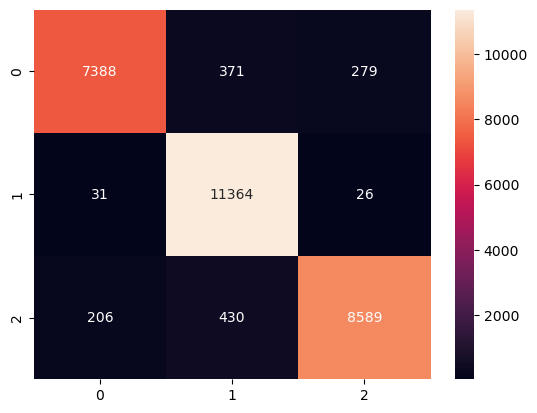

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()


In [12]:
import joblib

joblib.dump(lr, "../backend/model.pkl")
joblib.dump(vectorizer, "../backend/vectorizer.pkl")


['../backend/vectorizer.pkl']